# Testing Threonine Function Within Yeast 9 Model

In this library, the goal is to test the ideal concentration of Threonine for growth and to test it's necessecity in regard to gene knockouts. This will be done via the Yeast 9 model that has 1120 of the listed genes in the SGA database. 
First the model will find the minimum concentration threonine necessary for a minimal media (as well as anything else that's needed to make total sure that threonine is the only thing that might be preventing growth) which will be done by model.minimum commands. 
Once that is done, the model will go one by one knocking out each gene in varying threonine concentrations (25%, 50%, 100%, 200%, and 300%).

This would not be possible without Dr. Bernstein in BME 3340 in addition to the following sources:
SGD. (2019). Saccharomyces Genome Database | SGD. Yeastgenome.org. https://www.yeastgenome.org/​

‌Chik, J. K., Su, X. B., Klepin, S., Raygoza, J., & Pillus, L. (2024). Non-canonical chromatin-based functions for the threonine metabolic pathway. Scientific Reports, 14(1), 22629–22629. https://doi.org/10.1038/s41598-024-72394-z​

Zhang, C., Sánchez, B. J., Li, F., Eiden, C. W. Q., Scott, W. T., Liebal, U. W., Blank, L. M., Mengers, H. G., Anton, M., Rangel, A. T., Mendoza, S. N., Zhang, L., Nielsen, J., Lu, H., & Kerkhoven, E. J. (2024). Yeast9: a consensus genome-scale metabolic model for S. cerevisiae curated by the community. Molecular Systems Biology, 20(10), 1134–1150. https://doi.org/10.1038/s44320-024-00060-7

The following source is what I referenced for minimal media:
Lorsch, J. (2013). Laboratory methods in enzymology. Cell, lipid and carbohydrate. Elsevier/Ap. https://www.elsevier.com/books/laboratory-methods-in-enzymology-cell-lipid-and-carbohydrate/lorsch/978-0-12-420067-8


In [2]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [ ]:
#Imports 
import cobra
model = cobra.io.read_sbml_model("../../model/yeast-GEM.xml")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
thr_rxn = model.metabolites.get_by_id("s_0285") # gather threonine
thr_rxn

In [ ]:
for rxn in model.reactions: # gather all reactions that have theronine in it
    if "threonine" in rxn.name.lower() or "thr" in rxn.name.lower():
        print(rxn.id, "|", rxn.name)

As shown here there are many reactions that use threonine!
Now, we need to find the minimal media of yeast. To do this, we will use the minimal media function provided by cobra, the recipe for minimal media that we will be referencing is Lorsch's.

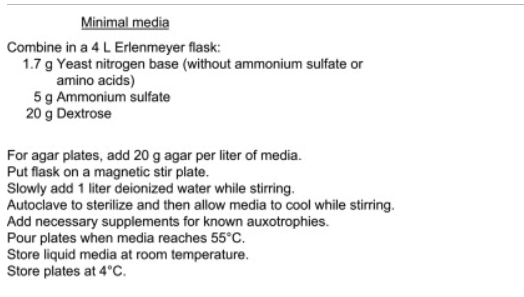

In [ ]:
base_media_yeast9 = {
    # Carbon source
    'r_1712': 10,   # glucose

    # Nitrogen source
    'r_1654': 5,    # ammonium

    # Sulfur / phosphate
    'r_1749': 5,    # sulfate
    'r_2005': 2,    # phosphate

    # Oxygen
    'r_1989': 20,   # oxygen

    # Always available
    'r_1832': 1000, # H2O
    'r_1820': 1000, # H+
    'r_1671': 1000, # CO2

    # Major ions
    'r_1663': 100,  # K+
    'r_1651': 100,  # Mg2+

    # Trace metals
    'r_1641': 10,   # Fe2+
    'r_1672': 10,   # Zn2+
    'r_1634': 5,    # Cu2+

    # Testable marker
    'r_1598' : 1000, #Threonine
}
# NA+, Cl-, Ca2+, Fe3+, Mn2+, Co2+ were not in the databese.


In [ ]:
#Minimal media function provided by Dr. Bernstein. Checking to see minimal amount of units needed for each molecule
with model as model_t:
    for rxn_id, uptake in base_media_yeast9.items():
        met = list(model.exchanges.get_by_id(rxn_id).metabolites.keys())[0]
        model.add_boundary(met, type="sink", reaction_id=rxn_id+'_tmp',lb=-1*uptake,ub=1000)
        
    for ex in model_t.exchanges:
        ex.lower_bound = -1000
        ex.upper_bound = 1000

    mm = cobra.medium.minimal_medium(model_t,0.1,minimize_components=10)
mm

In [ ]:
# adds the corresponding name to each reaction
for rxn_id in mm.index:
    rxn = model.reactions.get_by_id(rxn_id)
    met = list(rxn.metabolites.keys())[0]
    mn = print(rxn_id, "->", met.id, "|", met.name)

Okay, so it seems that Threonine is not part of the minimal media. That's okay, this probably means that this model suplements it's own Threonine.
In order to find out the ideal amount of threonine, we will have to check the biomass reaction of threonine synthesis, which is r_1042 as shown above. After we find that number we can then calculate the number of units needed for growth, which can be adjusted to the percentages we need.

In [ ]:
model.objective = "r_1042" #only look at r_1042

sol = model.optimize()

print("growth:", sol.objective_value)
print("r_1042 flux:", sol.fluxes["r_1042"])

biomass = model.reactions.get_by_id("r_1042")
thr = model.metabolites.get_by_id("s_1045")
#all of this is mainly to check if the model works and if threonine is necessary

with model:
    model.objective = "r_1042"
    sol = model.optimize()

    thr_demand = abs(biomass.metabolites[thr]) * sol.objective_value #find the demand of threonine in terms of units per growth

    print("growth:", sol.objective_value)
    print("threonine demand:", thr_demand)

Wonderful! This is the amount of threonine we need to support the current growth rate in the minimal media provided. Now we can get the amounts of threonine based off the percentages provided (25%, 50%, 100%, 200% and 300%) and knock out the genes in order. 

In [ ]:
thr_levels = {
    '25%': 0.25 * thr_demand,
    '50%': 0.50 * thr_demand,
    '100%': thr_demand,
    '200%': 2.0 * thr_demand,
    '300%': 3.0 * thr_demand
} #array that allows us to keep the amounts of threonine in the same order

In [ ]:
results = [] #empty array to add results to
for gene in model.genes:
    for label, thr in thr_levels.items():
        with model:
            # knockout gene
            gene.knock_out()

            # set threonine uptake
            model.reactions.get_by_id('r_1911').lower_bound = -thr

            # optimize growth
            sol = model.optimize()

            # store result
            results.append({
                'gene': gene.id,
                'threonine_level': label,
                'thr_flux': thr,
                'growth_rate': sol.objective_value
            })

# convert to dataframe
df = pd.DataFrame(results)

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None) # to make it so we can see the entirety of the output. Not necessary, but makes it so we can look closer.
df

This will be incredibly difficult to look at, so let's see if we can find any particularly interesting results.

In [ ]:
df[df['growth_rate'] > 0] #only shows growth above 0.0

These are all of the grwoth rates above 0. There is still a large amount of data here, but we can now see the general treands easier. As it stand it seems like with threonine suppmementation can cause a noticable difference in the 25% to 100% range, but not much of an increase past the 100% mark. This will be easier seen within the graph set, that will ranomly take a gene and show its trendline it will be physically impossible to conclude anything from one giant graph, so this is the only way to see general trends. 
The immediate code below is mainly to show this point, that although this can be interpretable, it can be difficult to truly understand what this means.

In [ ]:
for gene in df['gene'].unique():
    subset = df[df['gene'] == gene]
    plt.plot(subset['threonine_level'], subset['growth_rate'], label=gene) #goes through each gene and adds it to graph

plt.xlabel('Threonine Level')
plt.ylabel('Growth Rate')
plt.show()

The lack of a legend here is because of how large the databse is. I then chose to allow the model to create some smaller graphs so the results can be seen more clearly. I found it difficult to make any sense otherwise especially due to the lack of a legend.

In [ ]:
all_genes = df['gene'].unique()
random_genes = np.random.choice(all_genes, size=5, replace=False)  # pick 5 random genes

for gene in random_genes:
    subset = df[df['gene'] == gene]
    plt.plot(subset['threonine_level'], subset['growth_rate'], label=gene, alpha = 0.5) #decrease opacity to observe overlap

plt.xlabel('Threonine Level')
plt.ylabel('Growth Rate')
plt.legend()
plt.show()